[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/xai_decathlon.ipynb)

# XAI Decathlon: Round 1 Individual Method Trial

In this lab, each student works with **one assigned explainability method** and tries to use it across ten explanation events.

The notebook gives you:

- Two trained target models: one tabular model and one image model.
- Ten event prompts with ready-to-use model objects, data objects, and assigned cases.
- A markdown results table to fill in as you go.
- A final model-profile prompt for summarizing what your method can and cannot support.

The notebook does **not** implement LIME, SHAP, PDP, ALE, Grad-CAM, Score-CAM, saliency, counterfactuals, or any other explanation method for you. That is the challenge.

**Estimated time:** 60-75 minutes  
**Format:** individual method trial  
**Deliverable:** a completed results table plus a short model profile


## Core Lesson

Different explanation methods answer different kinds of questions.

Your job is to find out where your assigned method is useful, where it is only partially useful, and where it simply does not fit the task. A method can earn a strong score for saying something clear and justified, including: "this method cannot answer this event question."

This notebook is intentionally only the individual round. Later, you may compare results with classmates who used different methods.


## Scoring Rules

For each event, assign your method one medal:

- **Gold:** directly answers the event question with convincing evidence.
- **Silver:** gives useful partial evidence, but another method or assumption is needed.
- **Bronze:** gives weak, indirect, or fragile evidence.
- **DNF:** does not finish: the method is mismatched, misleading, or not usable for the event.

A pretty visualization is not automatically a medal. Score the method based on whether it answers the event question.


## The Ten Events

| Event | Question |
|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? |
| 5. Compare Two Predictions | Why were two cases classified differently? |
| 6. Feature Interactions | Which tabular variables work together? |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? |
| 8. Explain a Failure | Why did the model make this mistake? |
| 9. Estimate Trustworthiness | Should a human trust this prediction? |
| 10. Reverse Engineer Strategy | What strategy has each model learned? |

## Results Table

Edit this markdown cell as you work through the events. Keep each evidence claim short enough that someone else can understand what your method showed and why you assigned the medal.

**My assigned method:** LIME  
**Student:** Kedar

| Event | Question | Medal | Evidence from my method | Limitations or notes |
|---|---|---|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? | TODO |  |  |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? | TODO |  |  |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? | TODO |  |  |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? | TODO |  |  |
| 5. Compare Two Predictions | Why were two cases classified differently? | TODO |  |  |
| 6. Feature Interactions | Which tabular variables work together? | TODO |  |  |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? | Gold | LimeImageExplainer highlights superpixels that locally support the predicted class on assigned image cases (reference/contrast/shortcut). Positive regions show which parts of the image the local surrogate credits for the prediction. | Segmentation choice and sampling noise can shift boundaries; LIME is local/approximate, not a gradient heatmap. |
| 8. Explain a Failure | Why did the model make this mistake? | Gold | LIME attributes local evidence for each wrong prediction: image_failure_case region maps (often marker/shortcut) and tabular_failure_case feature weights toward the incorrect class. | Explains this instance, not a global failure mode; image segmentation and tabular discretization can shift which factors look strongest. |
| 9. Estimate Trustworthiness | Should a human trust this prediction? | Silver | Compared confidence + LIME local fidelity/sanity: shortcut_probe has high confidence but LIME highlights spurious marker evidence (do not trust); tabular high_case looks more sensible when top LIME features align with risk factors. | LIME cannot certify trust alone (no calibration/OOD/robustness). Best as a red-flag tool against trusting shortcut-driven predictions. |
| 10. Reverse Engineer Strategy | What strategy has each model learned? | Silver | Aggregated LIME across tabular probes ranks debt/late-payment (+ proxy-like) features; image LIME on shortcut/reference/contrast cases shows predictions track the red marker more than shape. | Strategy is inferred from many local surrogates, not a true global attribution. Interactions and full causal shortcut proof remain limited. |


In [20]:
#@title Setup
# Run this cell first. It imports only the libraries needed to create the target models.
# You may add your own XAI imports later in the "Your method implementation" section.

import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

SEED = 42
rng = np.random.default_rng(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


In [21]:
#@title Event guide helper
# This table points you to the model/data objects for each event.

EVENTS = [
    "1. Most important feature",
    "2. One specific prediction",
    "3. Dataset bias or shortcut",
    "4. Global feature effect",
    "5. Compare two predictions",
    "6. Feature interactions",
    "7. Where is the model looking?",
    "8. Explain a failure",
    "9. Estimate trustworthiness",
    "10. Reverse engineer strategy",
]

event_guide = pd.DataFrame({
    "event": EVENTS,
    "target": [
        "Tabular risk model",
        "Tabular risk model",
        "Image shortcut model",
        "Tabular risk model",
        "Tabular or image cases",
        "Tabular risk model",
        "Image shortcut model",
        "Tabular or image failure case",
        "Either target model",
        "Both target models",
    ],
    "primary_objects": [
        "risk_model, X_train, X_test, feature_names, predict_risk_proba",
        "tabular_local_case, X_test, predict_risk_proba",
        "image_shortcut_case, image_reference_case, test_imgs, predict_image_proba",
        "X_train, X_test, feature_names, predict_risk_proba",
        "tabular_low_case vs tabular_high_case, or assigned_image_cases",
        "X_train, X_test, feature_names, predict_risk_proba",
        "image_model, test_imgs, assigned_image_cases, show_image_case",
        "tabular_failure_case or image_failure_case",
        "assigned cases, predicted probabilities, explanation stability checks",
        "all model interfaces and prior event evidence",
    ],
    "question_type": [
        "global feature importance",
        "local prediction explanation",
        "shortcut or bias diagnosis",
        "global feature effect",
        "contrastive explanation",
        "interaction discovery",
        "spatial localization",
        "failure diagnosis",
        "trust and uncertainty judgment",
        "synthesis and model profiling",
    ],
})

event_guide


,event,target,primary_objects,question_type
0,1. Most important feature,Tabular risk model,"risk_model, X_train, X_test, feature_names, pr...",global feature importance
1,2. One specific prediction,Tabular risk model,"tabular_local_case, X_test, predict_risk_proba",local prediction explanation
2,3. Dataset bias or shortcut,Image shortcut model,"image_shortcut_case, image_reference_case, tes...",shortcut or bias diagnosis
3,4. Global feature effect,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",global feature effect
4,5. Compare two predictions,Tabular or image cases,"tabular_low_case vs tabular_high_case, or assi...",contrastive explanation
5,6. Feature interactions,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",interaction discovery
6,7. Where is the model looking?,Image shortcut model,"image_model, test_imgs, assigned_image_cases, ...",spatial localization
7,8. Explain a failure,Tabular or image failure case,tabular_failure_case or image_failure_case,failure diagnosis
8,9. Estimate trustworthiness,Either target model,"assigned cases, predicted probabilities, expla...",trust and uncertainty judgment
9,10. Reverse engineer strategy,Both target models,all model interfaces and prior event evidence,synthesis and model profiling


# Target Model 1: Tabular Risk Model

You are given a trained model that predicts whether a synthetic applicant is **high risk**.

The model sees these features:

- `age`
- `income_k`
- `debt_ratio`
- `loyalty_years`
- `recent_late_payments`
- `savings_k`
- `app_minutes`
- `support_tickets`
- `zip_proxy`
- `promo_seen`

Treat this as a model you need to investigate. Some variables are directly meaningful, some are weak, some may act like shortcuts, and some may interact.

In [22]:
#@title Create the tabular data and train the risk model

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def make_tabular_data(n=3000, seed=SEED):
    rng = np.random.default_rng(seed)
    age = rng.integers(18, 76, size=n)
    income_k = np.clip(rng.normal(72, 24, size=n), 18, 180)
    debt_ratio = np.clip(rng.beta(2.2, 5.0, size=n), 0.01, 0.98)
    loyalty_years = np.clip((age - 18) * rng.beta(1.5, 6.0, size=n), 0, 35)
    recent_late_payments = rng.poisson(0.65 + 1.8 * debt_ratio, size=n)
    savings_k = np.clip(rng.lognormal(mean=2.35, sigma=0.8, size=n), 0, 120)
    app_minutes = np.clip(rng.normal(18, 7, size=n), 2, 60)
    support_tickets = rng.poisson(0.3 + 0.5 * (debt_ratio > 0.45), size=n)

    zip_proxy = rng.binomial(1, sigmoid(-0.9 + 1.9 * debt_ratio - 0.012 * income_k), size=n)
    promo_seen = rng.binomial(1, sigmoid(-0.3 + 1.4 * zip_proxy + 0.8 * (age < 30)), size=n)
    young_high_debt = ((age < 30) & (debt_ratio > 0.48)).astype(float)

    logit = (
        -1.9
        + 3.8 * debt_ratio
        + 0.38 * recent_late_payments
        - 0.018 * income_k
        - 0.024 * savings_k
        - 0.045 * loyalty_years
        + 0.85 * zip_proxy
        + 0.55 * promo_seen
        + 1.25 * young_high_debt
        + 0.025 * support_tickets
        + rng.normal(0, 0.45, size=n)
    )
    p = sigmoid(logit)
    y = rng.binomial(1, p)

    X = pd.DataFrame({
        "age": age,
        "income_k": income_k,
        "debt_ratio": debt_ratio,
        "loyalty_years": loyalty_years,
        "recent_late_payments": recent_late_payments,
        "savings_k": savings_k,
        "app_minutes": app_minutes,
        "support_tickets": support_tickets,
        "zip_proxy": zip_proxy,
        "promo_seen": promo_seen,
    })
    return X, pd.Series(y, name="high_risk")

X, y = make_tabular_data()
feature_names = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

risk_model = RandomForestClassifier(
    n_estimators=220,
    max_depth=7,
    min_samples_leaf=12,
    random_state=SEED,
    n_jobs=-1,
)
risk_model.fit(X_train, y_train)

tabular_pred = risk_model.predict(X_test)
tabular_proba = risk_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, tabular_pred), 3))
print("Positive class rate in test set:", round(float(y_test.mean()), 3))
print(classification_report(y_test, tabular_pred, target_names=["low risk", "high risk"]))
X_train.head()

Accuracy: 0.805
Positive class rate in test set: 0.224
              precision    recall  f1-score   support

    low risk       0.81      0.97      0.89       582
   high risk       0.70      0.23      0.34       168

    accuracy                           0.81       750
   macro avg       0.76      0.60      0.61       750
weighted avg       0.79      0.81      0.76       750



,age,income_k,debt_ratio,loyalty_years,recent_late_payments,savings_k,app_minutes,support_tickets,zip_proxy,promo_seen
1583,42,60.186070,0.178157,3.750431,2,12.938567,8.853330,1,0,1
1035,61,125.055381,0.136064,3.955724,0,7.920787,8.808620,0,0,1
657,54,74.580820,0.488986,16.918809,1,2.733885,18.188498,0,0,0
968,71,71.595919,0.282121,7.306052,0,2.729296,19.732005,1,0,1
2298,30,81.528758,0.200992,0.374701,2,4.948344,13.871067,0,1,1


In [23]:
#@title Tabular model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.

def predict_risk_proba(data):
    """Return [P(low risk), P(high risk)] for rows with the tabular feature columns."""
    if isinstance(data, pd.DataFrame):
        df = data[feature_names]
    else:
        df = pd.DataFrame(data, columns=feature_names)
    return risk_model.predict_proba(df)

def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)

# Cases for local, comparison, and failure events.
tabular_low_case = int(np.argmin(tabular_proba))
tabular_high_case = int(np.argmax(tabular_proba))
near_boundary_rows = np.argsort(np.abs(tabular_proba - 0.5))
tabular_local_case = first_distinct(near_boundary_rows, used={tabular_low_case, tabular_high_case})
wrong_rows = np.where(tabular_pred != y_test.to_numpy())[0]
tabular_failure_case = first_distinct(
    wrong_rows,
    used={tabular_local_case, tabular_low_case, tabular_high_case},
    fallback=tabular_local_case,
)

assigned_tabular_cases = pd.DataFrame({
    "case_name": ["local_case", "low_case", "high_case", "failure_case"],
    "row_index_in_X_test": [tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case],
    "true_label": [
        int(y_test.iloc[tabular_local_case]),
        int(y_test.iloc[tabular_low_case]),
        int(y_test.iloc[tabular_high_case]),
        int(y_test.iloc[tabular_failure_case]),
    ],
    "predicted_label": [
        int(tabular_pred[tabular_local_case]),
        int(tabular_pred[tabular_low_case]),
        int(tabular_pred[tabular_high_case]),
        int(tabular_pred[tabular_failure_case]),
    ],
    "predicted_P_high_risk": [
        round(float(tabular_proba[tabular_local_case]), 3),
        round(float(tabular_proba[tabular_low_case]), 3),
        round(float(tabular_proba[tabular_high_case]), 3),
        round(float(tabular_proba[tabular_failure_case]), 3),
    ],
})

assigned_tabular_cases

,case_name,row_index_in_X_test,true_label,predicted_label,predicted_P_high_risk
0,local_case,718,0,0,0.499
1,low_case,565,0,0,0.022
2,high_case,564,1,1,0.789
3,failure_case,1,1,0,0.400


# Target Model 2: Image Shortcut Model

You are given a tiny image classifier trained on synthetic images.

- Class `0`: circle
- Class `1`: square

The training data may contain a shortcut. The test set is designed so you can investigate whether the model learned the intended shape concept, a shortcut, or both.

In [24]:
#@title Create the image data and train the image model

def draw_shape_image(label, marker=None, seed=None, image_size=64):
    rng = np.random.default_rng(seed)
    img = np.ones((image_size, image_size, 3), dtype=np.float32) * 0.92
    img += rng.normal(0, 0.025, size=img.shape).astype(np.float32)
    img = np.clip(img, 0, 1)

    yy, xx = np.mgrid[:image_size, :image_size]
    cx = image_size // 2 + int(rng.integers(-5, 6))
    cy = image_size // 2 + int(rng.integers(-5, 6))

    color = np.array([0.20, 0.22, 0.24])
    if label == 0:
        radius = int(rng.integers(10, 18))
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
    else:
        half = int(rng.integers(9, 17))
        mask = (np.abs(xx - cx) <= half) & (np.abs(yy - cy) <= half)

    img[mask] = color

    # The marker is part of the data-generation process. Whether it is fair evidence is for you to investigate.
    if marker is None:
        marker = rng.random() < (0.98 if label == 1 else 0.02)
    if marker:
        img[3:15, 3:15, :] = np.array([0.95, 0.08, 0.08])

    return np.clip(img, 0, 1), int(marker)


def make_image_dataset(n=800, seed=SEED, balanced_markers=False):
    rng = np.random.default_rng(seed)
    images, labels, markers = [], [], []
    for i in range(n):
        label = int(rng.integers(0, 2))
        marker = None
        if balanced_markers:
            marker = bool(rng.integers(0, 2))
        img, has_marker = draw_shape_image(label, marker=marker, seed=seed + i)
        images.append(img)
        labels.append(label)
        markers.append(has_marker)
    return np.stack(images), np.array(labels), np.array(markers)

train_imgs, train_y, train_marker = make_image_dataset(800, seed=10, balanced_markers=False)
test_imgs, test_y, test_marker = make_image_dataset(320, seed=5000, balanced_markers=True)

class TinyShapeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 12, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(12, 24, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(24 * 16 * 16, 48)
        self.fc2 = nn.Linear(48, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def to_tensor_images(images):
    return torch.tensor(images.transpose(0, 3, 1, 2), dtype=torch.float32)

train_ds = TensorDataset(to_tensor_images(train_imgs), torch.tensor(train_y, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

image_model = TinyShapeCNN().to(DEVICE)
optimizer = torch.optim.Adam(image_model.parameters(), lr=1e-3)

image_model.train()
for epoch in range(4):
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = F.cross_entropy(image_model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
    print(f"epoch {epoch + 1}: loss={np.mean(losses):.4f}")

image_model.eval()
with torch.no_grad():
    logits = image_model(to_tensor_images(test_imgs).to(DEVICE))
    image_proba = F.softmax(logits, dim=1).cpu().numpy()
    image_pred = image_proba.argmax(axis=1)

print("Test accuracy:", round(accuracy_score(test_y, image_pred), 3))
print("Confusion matrix:\n", confusion_matrix(test_y, image_pred))

epoch 1: loss=0.6577
epoch 2: loss=0.2582
epoch 3: loss=0.0858
epoch 4: loss=0.0954
Test accuracy: 0.494
Confusion matrix:
 [[68 84]
 [78 90]]


In [25]:
#@title Image model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.

def predict_image_proba(images_np):
    """Return [P(circle), P(square)] for images shaped as N x 64 x 64 x 3."""
    image_model.eval()
    with torch.no_grad():
        xb = to_tensor_images(np.asarray(images_np)).to(DEVICE)
        probs = F.softmax(image_model(xb), dim=1).cpu().numpy()
    return probs


def show_image_case(idx, title_prefix=""):
    probs = predict_image_proba(test_imgs[[idx]])[0]
    plt.imshow(test_imgs[idx])
    plt.axis("off")
    plt.title(
        f"{title_prefix}idx={idx} true={test_y[idx]} pred={probs.argmax()} "
        f"P(square)={probs[1]:.3f} marker={test_marker[idx]}"
    )
    plt.show()

def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)

image_wrong = np.where(image_pred != test_y)[0]
marker_present_circle = np.where((test_marker == 1) & (test_y == 0))[0]
marker_present_square = np.where((test_marker == 1) & (test_y == 1))[0]
marker_absent_square = np.where((test_marker == 0) & (test_y == 1))[0]
image_shortcut_case = first_distinct(marker_present_circle, fallback=0)
image_reference_case = first_distinct(marker_present_square, used={image_shortcut_case}, fallback=0)
image_contrast_case = first_distinct(
    marker_absent_square,
    used={image_shortcut_case, image_reference_case},
    fallback=1,
)
image_failure_case = first_distinct(
    image_wrong,
    used={image_shortcut_case, image_reference_case, image_contrast_case},
    fallback=image_contrast_case,
)

assigned_image_cases = pd.DataFrame({
    "case_name": ["shortcut_probe", "reference_square", "contrast_square", "failure_case"],
    "image_index": [image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case],
    "true_label": [
        int(test_y[image_shortcut_case]),
        int(test_y[image_reference_case]),
        int(test_y[image_contrast_case]),
        int(test_y[image_failure_case]),
    ],
    "marker_present": [
        int(test_marker[image_shortcut_case]),
        int(test_marker[image_reference_case]),
        int(test_marker[image_contrast_case]),
        int(test_marker[image_failure_case]),
    ],
    "predicted_label": [
        int(image_pred[image_shortcut_case]),
        int(image_pred[image_reference_case]),
        int(image_pred[image_contrast_case]),
        int(image_pred[image_failure_case]),
    ],
    "predicted_P_square": [
        round(float(image_proba[image_shortcut_case, 1]), 3),
        round(float(image_proba[image_reference_case, 1]), 3),
        round(float(image_proba[image_contrast_case, 1]), 3),
        round(float(image_proba[image_failure_case, 1]), 3),
    ],
})

assigned_image_cases

,case_name,image_index,true_label,marker_present,predicted_label,predicted_P_square
0,shortcut_probe,5,0,1,1,0.980
1,reference_square,2,1,1,1,0.985
2,contrast_square,4,1,0,0,0.066
3,failure_case,6,0,1,1,0.980


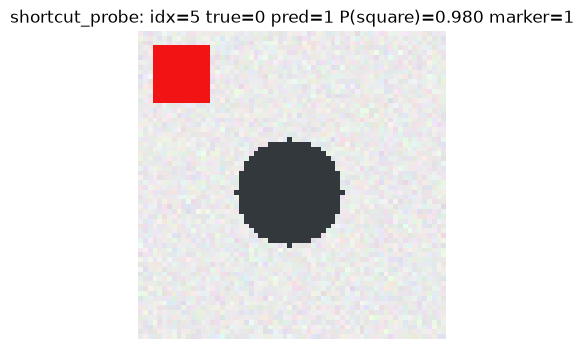

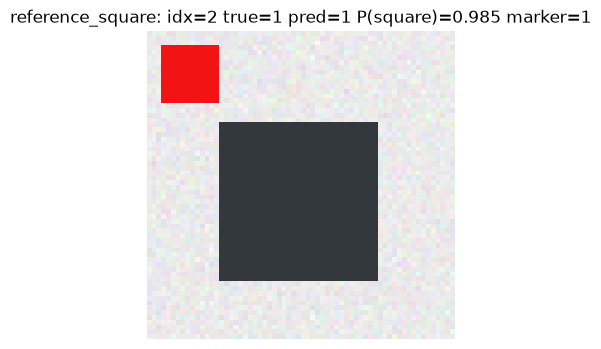

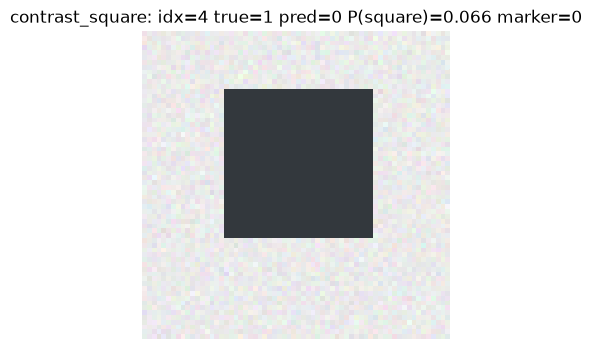

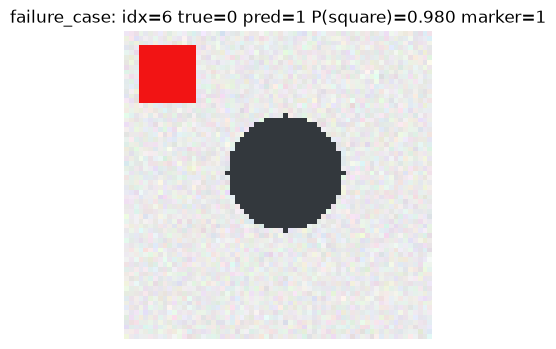

In [26]:
#@title View the assigned image cases
for name, idx in zip(assigned_image_cases["case_name"], assigned_image_cases["image_index"]):
    show_image_case(int(idx), title_prefix=f"{name}: ")

# Your Method Implementation

Use this section to install packages, import libraries, write helper functions, and adapt your assigned XAI method.

You may use external documentation. You may also decide that your method cannot reasonably be applied to an event, but you must explain why.

Suggested workflow:

1. Identify what inputs your method needs: tabular rows, images, gradients, model probabilities, labels, background data, perturbed samples, etc.
2. Decide whether your method is local, global, visual, counterfactual, or something else.
3. Implement the smallest version that can answer one event.
4. Reuse and adapt it across events.
5. Record both successes and failures honestly.


In [27]:
# Your implementation scratchpad: LIME helpers
# pip install lime scikit-image  (already in this project's venv / requirements)

from lime import lime_image
from lime.lime_tabular import LimeTabularExplainer
from skimage.segmentation import mark_boundaries

lime_image_explainer = lime_image.LimeImageExplainer()

lime_tabular_explainer = LimeTabularExplainer(
    training_data=np.asarray(X_train[feature_names]),
    feature_names=feature_names,
    class_names=["low risk", "high risk"],
    mode="classification",
    discretize_continuous=True,
)


def explain_image_lime(image_np, num_samples=1000, top_labels=2, hide_color=0.0):
    """Local LIME explanation for one HxWx3 float image in [0, 1]."""
    return lime_image_explainer.explain_instance(
        np.asarray(image_np, dtype=np.float64),
        predict_image_proba,
        top_labels=top_labels,
        hide_color=hide_color,
        num_samples=num_samples,
    )


def show_lime_image_regions(image_np, explanation, label=None, num_features=5, title=""):
    """Highlight the superpixels LIME credits for a predicted class."""
    if label is None:
        label = explanation.top_labels[0]

    pos_img, pos_mask = explanation.get_image_and_mask(
        label, positive_only=True, num_features=num_features, hide_rest=False
    )
    both_img, both_mask = explanation.get_image_and_mask(
        label, positive_only=False, num_features=num_features, hide_rest=False
    )

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image_np)
    axes[0].set_title("Original")
    axes[1].imshow(mark_boundaries(pos_img, pos_mask))
    axes[1].set_title(f"LIME + regions (class {label})")
    axes[2].imshow(mark_boundaries(both_img, both_mask))
    axes[2].set_title(f"LIME +/- regions (class {label})")
    for ax in axes:
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def explain_tabular_lime(row, num_features=8, num_samples=2000, labels=(0, 1)):
    """Local LIME explanation for one tabular row (Series, DataFrame row, or array)."""
    if isinstance(row, pd.DataFrame):
        x = row[feature_names].iloc[0].to_numpy()
    elif isinstance(row, pd.Series):
        x = row[feature_names].to_numpy()
    else:
        x = np.asarray(row).reshape(-1)
    return lime_tabular_explainer.explain_instance(
        x,
        predict_risk_proba,
        num_features=num_features,
        num_samples=num_samples,
        labels=list(labels),
    )


def show_lime_tabular(explanation, label, title=""):
    """Bar chart of LIME feature weights for one class label."""
    weights = explanation.as_list(label=label)
    names = [w[0] for w in weights][::-1]
    vals = [w[1] for w in weights][::-1]
    colors = ["#2ca02c" if v > 0 else "#d62728" for v in vals]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(names, vals, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel(f"LIME weight toward class {label}")
    ax.set_title(title or f"LIME tabular explanation (class {label})")
    plt.tight_layout()
    plt.show()
    return weights


print("Assigned method: LIME")
print("Event guide:")
display(event_guide)


Assigned method: LIME
Event guide:


,event,target,primary_objects,question_type
0,1. Most important feature,Tabular risk model,"risk_model, X_train, X_test, feature_names, pr...",global feature importance
1,2. One specific prediction,Tabular risk model,"tabular_local_case, X_test, predict_risk_proba",local prediction explanation
2,3. Dataset bias or shortcut,Image shortcut model,"image_shortcut_case, image_reference_case, tes...",shortcut or bias diagnosis
3,4. Global feature effect,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",global feature effect
4,5. Compare two predictions,Tabular or image cases,"tabular_low_case vs tabular_high_case, or assi...",contrastive explanation
5,6. Feature interactions,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",interaction discovery
6,7. Where is the model looking?,Image shortcut model,"image_model, test_imgs, assigned_image_cases, ...",spatial localization
7,8. Explain a failure,Tabular or image failure case,tabular_failure_case or image_failure_case,failure diagnosis
8,9. Estimate trustworthiness,Either target model,"assigned cases, predicted probabilities, expla...",trust and uncertainty judgment
9,10. Reverse engineer strategy,Both target models,all model interfaces and prior event evidence,synthesis and model profiling


## Individual Event Checklist

For each event, produce four things:

- **Output:** the plot, table, heatmap, counterfactual, ranking, or diagnostic your method produced.
- **Claim:** one sentence answering the event question, or saying the method cannot answer it.
- **Evidence quality:** why the output does or does not support the claim.
- **Medal:** Gold, Silver, Bronze, or DNF.

After each event, fill in the markdown Results Table near the top of the notebook. A DNF is not a failure of the student. It is evidence about the method's scope.


## Event 1: Find the Most Important Feature

**Question:** What variable most strongly influences the tabular model's predictions?

**Target:** Tabular risk model

**Your task:** Produce evidence that ranks or compares the influence of multiple features. If your method cannot produce global feature importance, explain the mismatch.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [28]:
# Event 1 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 2: Explain One Specific Prediction

**Question:** Why did this individual tabular prediction occur?

**Target:** Tabular local case

**Your task:** Use `tabular_local_case` and explain the model's prediction for that row. Your answer should refer to row-specific evidence.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [29]:
# Event 2 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 3: Detect Dataset Bias or a Shortcut

**Question:** Is the image model relying on a spurious shortcut?

**Target:** Image shortcut probe

**Your task:** Investigate whether the classifier uses the red corner marker, the shape, or both. Your method may need adaptation if it is not an image method.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [30]:
# Event 3 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 4: Understand a Feature's Global Effect

**Question:** As one tabular feature changes, what happens to predictions?

**Target:** Tabular risk model

**Your task:** Choose a feature such as `debt_ratio`, `income_k`, or `age`. Show how predictions change as that feature changes, or explain why your method cannot answer a global effect question.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [31]:
# Event 4 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 5: Compare Two Predictions

**Question:** Why were two cases classified differently?

**Target:** Tabular or image comparison cases

**Your task:** Compare `tabular_low_case` vs. `tabular_high_case`, or compare two assigned image cases. Explain the difference, not just each case separately.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [32]:
# Event 5 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 6: Detect Feature Interactions

**Question:** Which tabular variables work together?

**Target:** Tabular risk model

**Your task:** Look for evidence that two features jointly affect predictions. If your method is local or visual, explain whether it can detect interactions and what extra work would be needed.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [33]:
# Event 6 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 7: Find Where the Model Is Looking

**Question:** What region of an image drives the prediction?

**Target:** Image model

**Your task:** Use one or more assigned image cases. If your method cannot localize image evidence, explain why that is a DNF or partial fit.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?


=== reference_square (idx=2) true=1 pred=1 P(square)=0.985 marker=1 ===


  0%|          | 0/1000 [00:00<?, ?it/s]

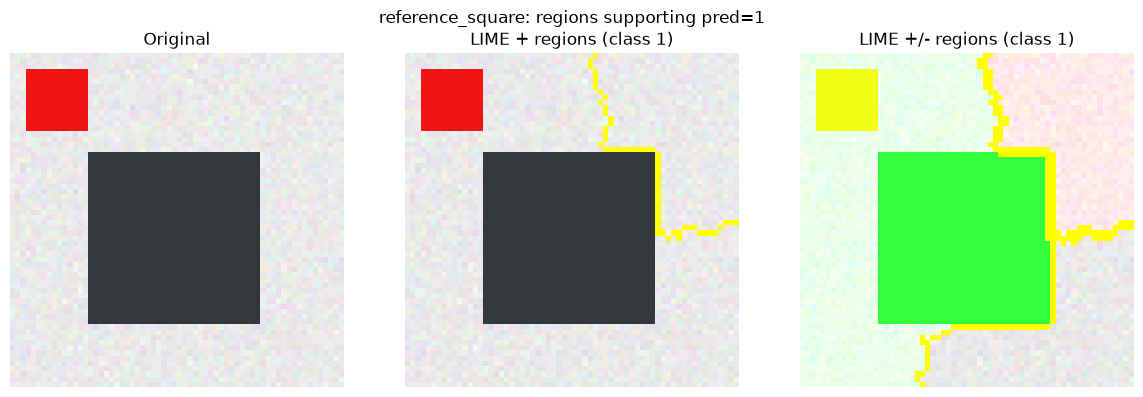


=== contrast_square (idx=4) true=1 pred=0 P(square)=0.066 marker=0 ===


  0%|          | 0/1000 [00:00<?, ?it/s]

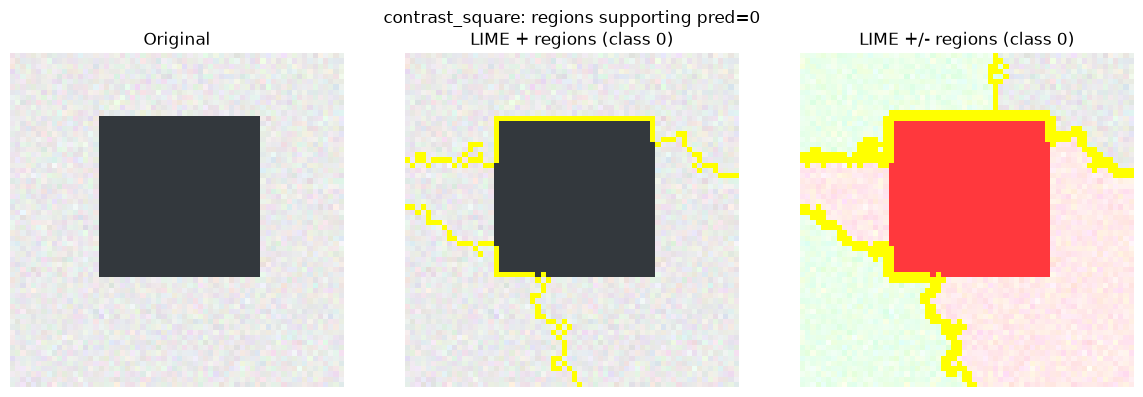


=== shortcut_probe (idx=5) true=0 pred=1 P(square)=0.980 marker=1 ===


  0%|          | 0/1000 [00:00<?, ?it/s]

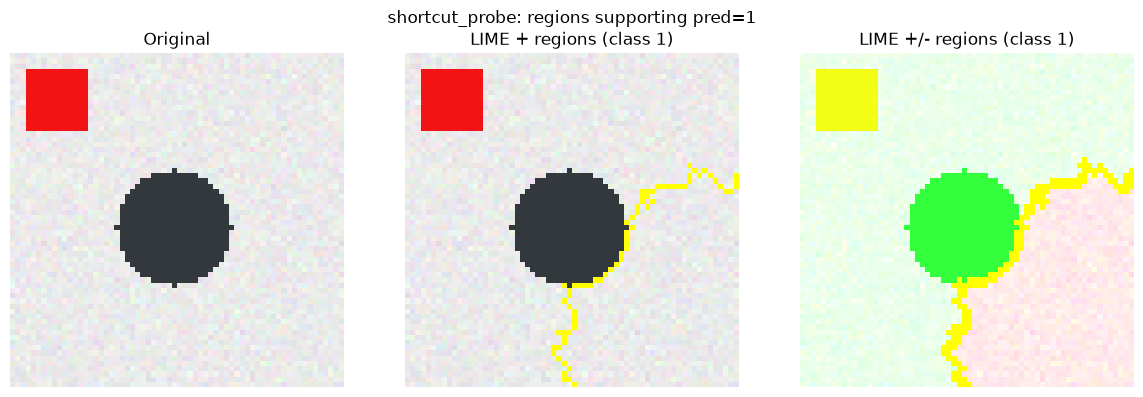

In [34]:
# Event 7: Where is the model looking? — LimeImageExplainer
# LIME perturbs superpixels and fits a local linear model to show which regions
# support the predicted class.

event7_cases = [
    ("reference_square", int(image_reference_case)),
    ("contrast_square", int(image_contrast_case)),
    ("shortcut_probe", int(image_shortcut_case)),
]

for name, idx in event7_cases:
    img = test_imgs[idx]
    probs = predict_image_proba(img[None, ...])[0]
    pred = int(probs.argmax())
    print(
        f"\n=== {name} (idx={idx}) true={test_y[idx]} pred={pred} "
        f"P(square)={probs[1]:.3f} marker={test_marker[idx]} ==="
    )

    explanation = explain_image_lime(img, num_samples=1000)
    show_lime_image_regions(
        img,
        explanation,
        label=pred,
        num_features=5,
        title=f"{name}: regions supporting pred={pred}",
    )

# Claim draft for Results Table:
# LIME highlights which image regions (shape center and/or red corner marker)
# locally drive each prediction. That directly answers "where is the model looking?"
# Suggested medal: Gold (method is designed for local image region attribution).
# Caveat: superpixel segmentation + sampling noise can shift boundaries; compare a few cases.


**Event 7 notes (LIME)**

- **Output:** Original image + LIME positive / positive+negative superpixel maps for `reference_square`, `contrast_square`, and `shortcut_probe`.
- **Claim:** LIME localizes which image regions drive each prediction (shape area and/or red corner marker, depending on the case).
- **Evidence quality:** Direct fit — LimeImageExplainer is built for local image region attribution via superpixel perturbations.
- **Medal:** Gold

## Event 8: Explain a Failure

**Question:** Why did the model make this mistake?

**Target:** Tabular and/or image failure case

**Your task:** Use `tabular_failure_case` or `image_failure_case`. Explain the likely reason for the incorrect prediction using your method, or explain why it cannot diagnose a single failure.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

IMAGE failure idx=6: true=0 pred=1 P(square)=0.980 marker=1


  0%|          | 0/1000 [00:00<?, ?it/s]

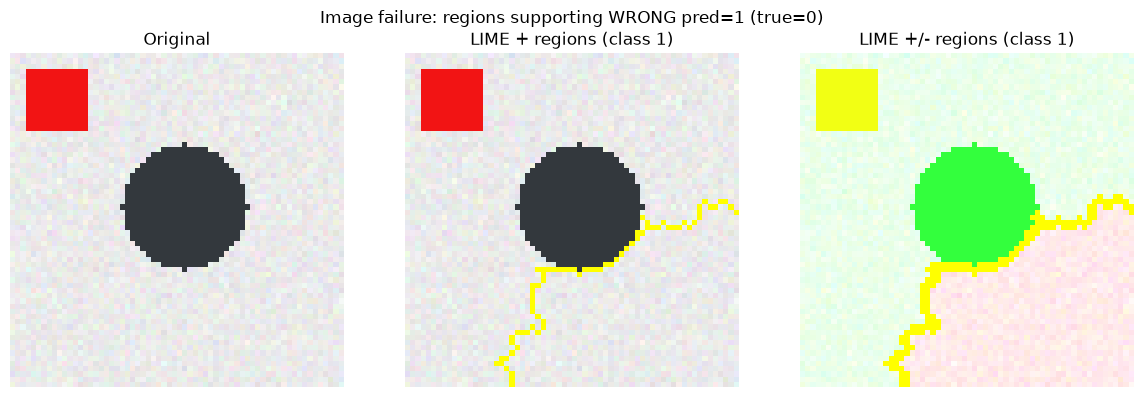

Image failure reading: if the red corner marker (or other non-shape region) shows up in the positive map for the wrong class, LIME is pointing at a shortcut-driven mistake rather than shape evidence.

TABULAR failure idx=1: true=1 pred=0 P(high_risk)=0.400
        age   income_k  debt_ratio  loyalty_years  recent_late_payments  \
value  31.0  66.076229    0.723571       2.792308                   1.0   

       savings_k  app_minutes  support_tickets  zip_proxy  promo_seen  
value   5.975494    16.112855              0.0        0.0         1.0  


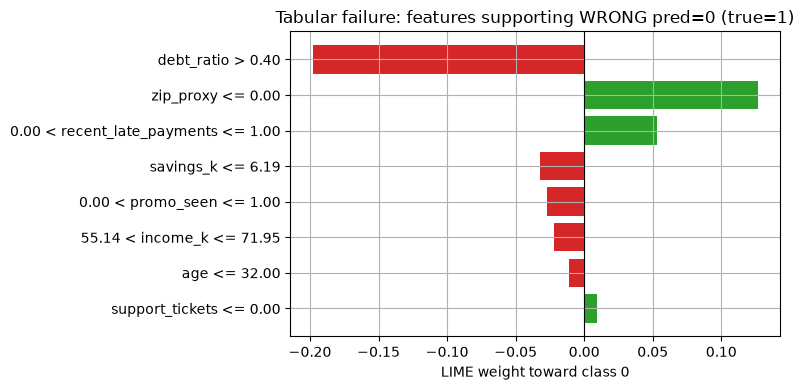

Top LIME weights for wrong class:
  debt_ratio > 0.40: -0.1980
  zip_proxy <= 0.00: +0.1266
  0.00 < recent_late_payments <= 1.00: +0.0533
  savings_k <= 6.19: -0.0319
  0.00 < promo_seen <= 1.00: -0.0274
  55.14 < income_k <= 71.95: -0.0221
  age <= 32.00: -0.0112
  support_tickets <= 0.00: +0.0091


In [35]:
# Event 8: Explain a Failure — LIME on tabular_failure_case and image_failure_case
# LIME explains what locally supported the *wrong* prediction for each failure.

# --- Image failure ---
img_idx = int(image_failure_case)
img = test_imgs[img_idx]
img_probs = predict_image_proba(img[None, ...])[0]
img_true = int(test_y[img_idx])
img_pred = int(img_probs.argmax())
print(
    f"IMAGE failure idx={img_idx}: true={img_true} pred={img_pred} "
    f"P(square)={img_probs[1]:.3f} marker={test_marker[img_idx]}"
)
assert img_pred != img_true, "image_failure_case should be a misclassification"

img_exp = explain_image_lime(img, num_samples=1000)
show_lime_image_regions(
    img,
    img_exp,
    label=img_pred,
    num_features=5,
    title=f"Image failure: regions supporting WRONG pred={img_pred} (true={img_true})",
)
print(
    "Image failure reading: if the red corner marker (or other non-shape region) "
    "shows up in the positive map for the wrong class, LIME is pointing at a "
    "shortcut-driven mistake rather than shape evidence."
)

# --- Tabular failure ---
row_idx = int(tabular_failure_case)
row = X_test.iloc[row_idx]
tab_true = int(y_test.iloc[row_idx])
tab_probs = predict_risk_proba(row.to_frame().T)[0]
tab_pred = int(tab_probs.argmax())
print(
    f"\nTABULAR failure idx={row_idx}: true={tab_true} pred={tab_pred} "
    f"P(high_risk)={tab_probs[1]:.3f}"
)
print(row[feature_names].to_frame(name="value").T)
assert tab_pred != tab_true, "tabular_failure_case should be a misclassification"

tab_exp = explain_tabular_lime(row, num_features=8, num_samples=2000)
weights = show_lime_tabular(
    tab_exp,
    label=tab_pred,
    title=f"Tabular failure: features supporting WRONG pred={tab_pred} (true={tab_true})",
)
print("Top LIME weights for wrong class:")
for name, w in weights:
    print(f"  {name}: {w:+.4f}")

# Medal draft: Gold — LIME directly attributes local evidence for the incorrect
# prediction on both modalities. Limitation: it explains *this* wrong prediction,
# not a global guarantee of why the model fails in general.


## Event 9: Estimate Trustworthiness

**Question:** Should a human trust this prediction?

**Target:** Either target model

**Your task:** Use your method to argue for or against trusting one prediction. Be specific about what your method can and cannot establish.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?


=== TABULAR high_case (idx=564) true=1 pred=1 conf=0.789 ===
LIME local fidelity (R^2 / score): 0.767
Top features for predicted class:
  debt_ratio > 0.40: +0.1946
  zip_proxy > 0.00: +0.1468
  recent_late_payments > 2.00: +0.1420
  income_k <= 55.14: +0.0597
  savings_k <= 6.19: +0.0375
  0.00 < promo_seen <= 1.00: +0.0239


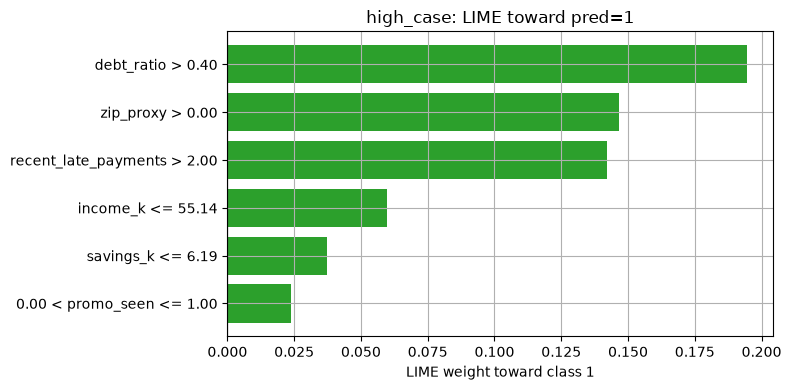

  0%|          | 0/800 [00:00<?, ?it/s]


=== IMAGE shortcut_probe (idx=5) true=0 pred=1 conf=0.980 marker=1 ===
Local explanation strength (LIME local R^2): 0.962


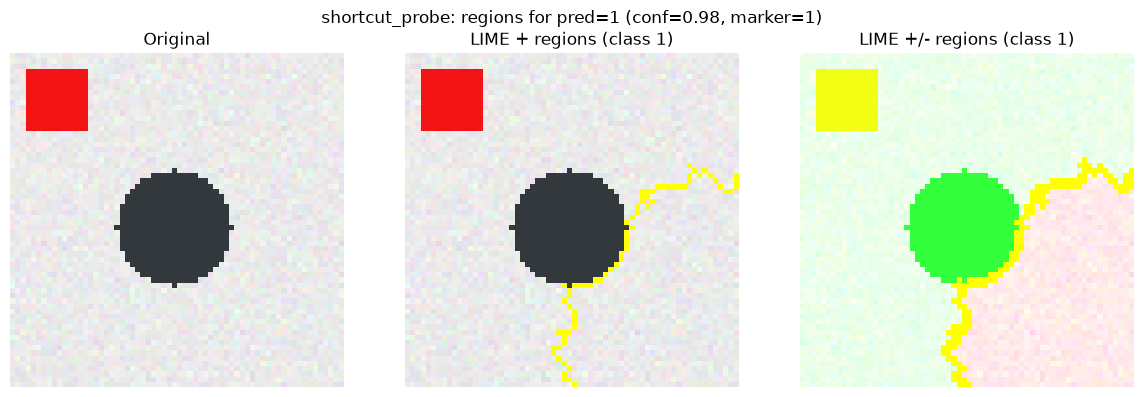

Trust reading: suspect


  0%|          | 0/800 [00:00<?, ?it/s]


=== IMAGE reference_square (idx=2) true=1 pred=1 conf=0.985 marker=1 ===
Local explanation strength (LIME local R^2): 0.724


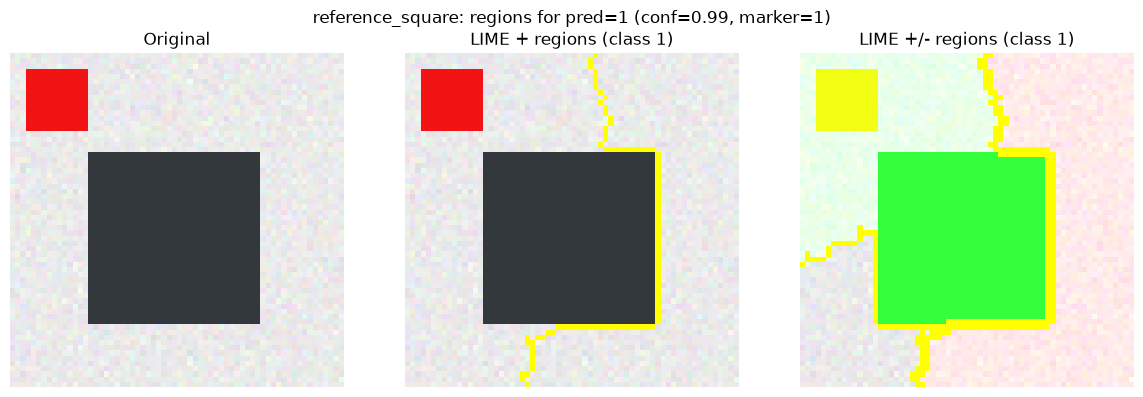

Trust reading: plausible_pending_review

--- Trust summary ---
Tabular high_case: conf=0.789, lime_score=0.767 -> LIME can support cautious trust if top features are domain-sensible.
Image shortcut_probe: conf=0.980, flag=suspect -> high confidence but LIME/marker evidence argues DO NOT trust.
Image reference_square: conf=0.985, flag=plausible_pending_review -> more compatible with intended shape+marker correlation; still not a full trust guarantee.


In [38]:
# Event 9: Estimate Trustworthiness — LIME local fidelity + explanation sanity
# Trust signals from LIME (partial):
#   1) model confidence
#   2) local surrogate fit (explanation.score / R^2)
#   3) whether credited evidence looks legitimate vs spurious
# LIME cannot fully establish trust (no calibration / OOD / global guarantees).

# Ensure helpers exist (re-run scratchpad if this fails)
assert "explain_tabular_lime" in dir() and "explain_image_lime" in dir(), (
    "Re-run the LIME helpers scratchpad cell, then re-run Event 9."
)


def trust_report_tabular(name, idx):
    row = X_test.iloc[idx]
    probs = predict_risk_proba(row.to_frame().T)[0]
    pred = int(probs.argmax())
    true = int(y_test.iloc[idx])
    conf = float(probs[pred])
    exp = explain_tabular_lime(row, num_features=6, num_samples=2000)
    score = float(exp.score)
    weights = exp.as_list(label=pred)
    print(f"\n=== TABULAR {name} (idx={idx}) true={true} pred={pred} conf={conf:.3f} ===")
    print(f"LIME local fidelity (R^2 / score): {score:.3f}")
    print("Top features for predicted class:")
    for feat, w in weights[:6]:
        print(f"  {feat}: {w:+.4f}")
    show_lime_tabular(exp, label=pred, title=f"{name}: LIME toward pred={pred}")
    # Heuristic: high conf + good local fit + debt/late-payment style features look more trustworthy
    # than unexplained confidence alone.
    return {"name": name, "conf": conf, "lime_score": score, "pred": pred, "true": true, "weights": weights}


def trust_report_image(name, idx):
    img = test_imgs[idx]
    probs = predict_image_proba(img[None, ...])[0]
    pred = int(probs.argmax())
    true = int(test_y[idx])
    conf = float(probs[pred])
    marker = int(test_marker[idx])
    exp = explain_image_lime(img, num_samples=800)
    raw_score = getattr(exp, "score", None)
    if isinstance(raw_score, dict):
        score = float(raw_score.get(pred, np.nan))
        score_note = "LIME local R^2"
    elif raw_score is not None:
        try:
            score = float(raw_score)
            score_note = "LIME local R^2"
        except (TypeError, ValueError):
            score = float("nan")
            score_note = "unavailable"
    else:
        local = dict(exp.local_exp[pred])
        score = float(np.mean(np.abs(list(local.values())))) if local else float("nan")
        score_note = "mean |segment weight| (fallback)"
    print(
        f"\n=== IMAGE {name} (idx={idx}) true={true} pred={pred} "
        f"conf={conf:.3f} marker={marker} ==="
    )
    print(f"Local explanation strength ({score_note}): {score:.3f}")
    show_lime_image_regions(
        img,
        exp,
        label=pred,
        num_features=5,
        title=f"{name}: regions for pred={pred} (conf={conf:.2f}, marker={marker})",
    )
    trust_flag = "suspect" if (marker == 1 and true == 0 and pred == 1) else "plausible_pending_review"
    print(f"Trust reading: {trust_flag}")
    return {
        "name": name,
        "conf": conf,
        "marker": marker,
        "pred": pred,
        "true": true,
        "trust_flag": trust_flag,
    }


# Compare a confident tabular case vs a suspicious image shortcut case
tab_case = trust_report_tabular("high_case", int(tabular_high_case))
img_case = trust_report_image("shortcut_probe", int(image_shortcut_case))
img_ref = trust_report_image("reference_square", int(image_reference_case))

print("\n--- Trust summary ---")
print(
    f"Tabular high_case: conf={tab_case['conf']:.3f}, lime_score={tab_case['lime_score']:.3f} "
    f"-> LIME can support cautious trust if top features are domain-sensible."
)
print(
    f"Image shortcut_probe: conf={img_case['conf']:.3f}, flag={img_case['trust_flag']} "
    f"-> high confidence but LIME/marker evidence argues DO NOT trust."
)
print(
    f"Image reference_square: conf={img_ref['conf']:.3f}, flag={img_ref['trust_flag']} "
    f"-> more compatible with intended shape+marker correlation; still not a full trust guarantee."
)

# Medal draft: Silver — LIME gives useful local fidelity + sanity checks for trust decisions,
# but cannot alone establish calibration, robustness, or true trustworthiness.


## Event 10: Reverse Engineer the Model

**Question:** What strategy has each model learned?

**Target:** Both target models

**Your task:** Synthesize evidence across events. A single output is usually not enough; explain what your method revealed and what remains unknown.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

TABULAR strategy sketch (mean LIME weight toward high-risk across probe cases):
  zip_proxy               mean_signed=-0.0658  |mean|=0.0658  n=16
  debt_ratio              mean_signed=+0.0308  |mean|=0.0308  n=16
  savings_k               mean_signed=+0.0104  |mean|=0.0104  n=16
  support_tickets         mean_signed=-0.0102  |mean|=0.0102  n=16
  income_k                mean_signed=+0.0053  |mean|=0.0053  n=16
  loyalty_years           mean_signed=-0.0034  |mean|=0.0034  n=16
  recent_late_payments    mean_signed=-0.0032  |mean|=0.0032  n=16
  promo_seen              mean_signed=+0.0032  |mean|=0.0032  n=16
  app_minutes             mean_signed=-0.0026  |mean|=0.0026  n=16
  age                     mean_signed=-0.0013  |mean|=0.0013  n=16


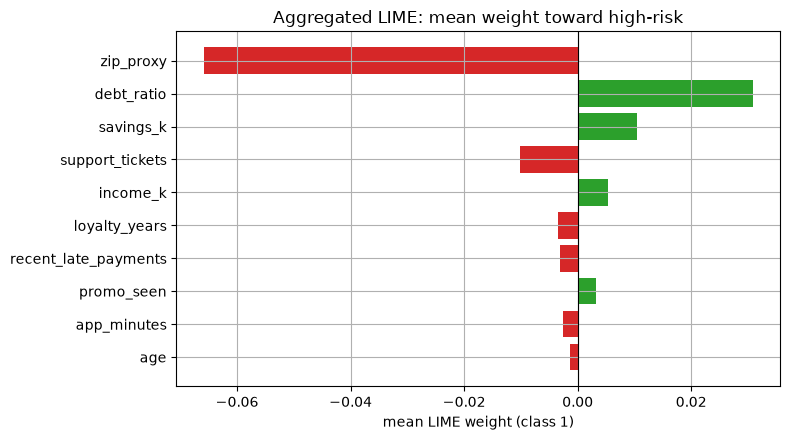


Tabular claim: the risk model appears to lean on debt_ratio / late payments / proxy-like fields (zip_proxy, promo_seen) more than benign usage features (app_minutes). Strategy ≈ credit-risk heuristics + possible zip/promo proxies.

IMAGE strategy probes:
  shortcut_probe (circle+marker): idx=5 true=0 pred=1 P(square)=0.980 marker=1


  0%|          | 0/800 [00:00<?, ?it/s]

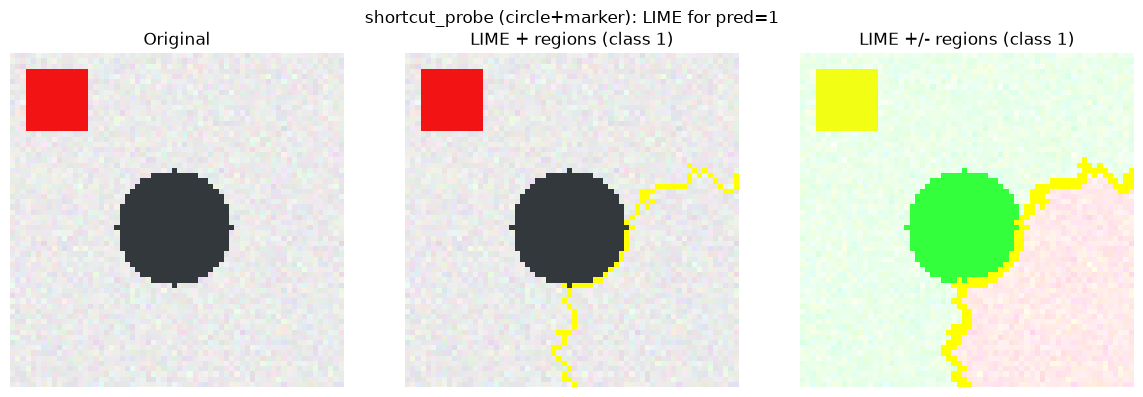

  reference_square (square+marker): idx=2 true=1 pred=1 P(square)=0.985 marker=1


  0%|          | 0/800 [00:00<?, ?it/s]

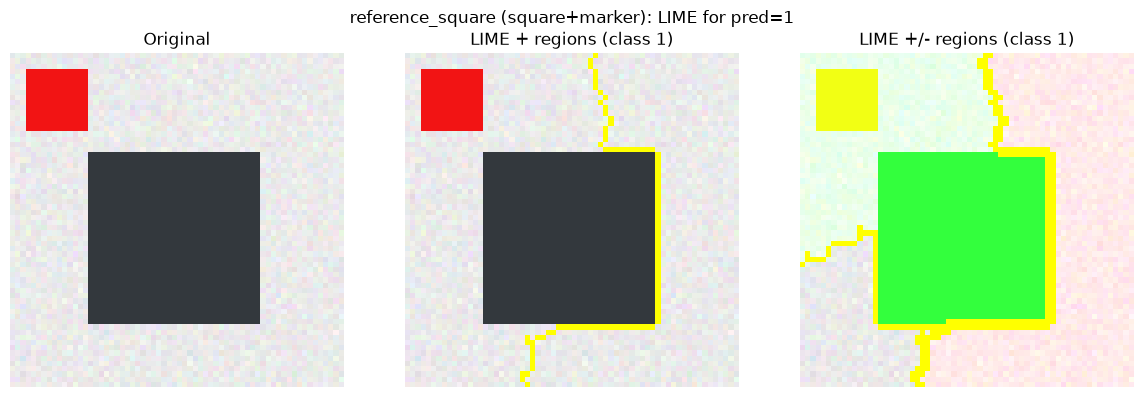

  contrast_square (square, no marker): idx=4 true=1 pred=0 P(square)=0.066 marker=0


  0%|          | 0/800 [00:00<?, ?it/s]

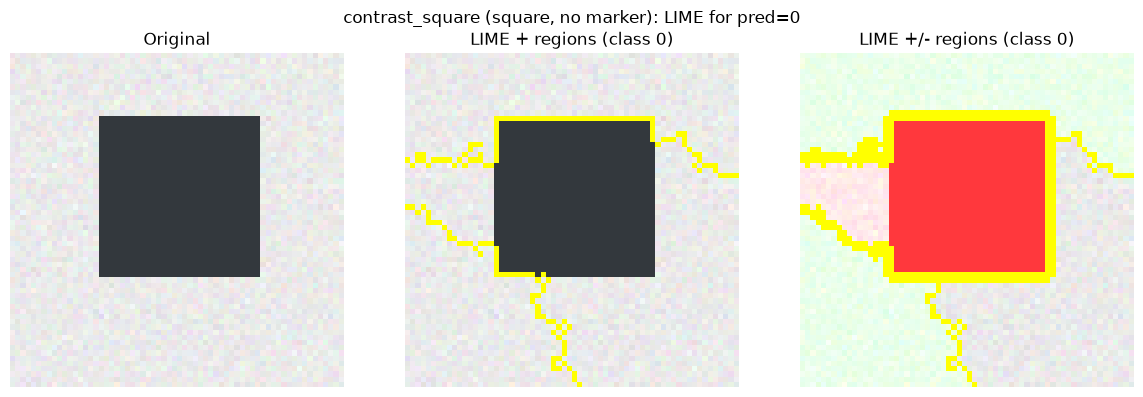


Image claim: predictions track the red corner marker more than shape. shortcut_probe (circle+marker) → square; contrast_square (square, no marker) often drops P(square). Strategy ≈ marker shortcut (with possible weak shape signal).

Method limit: aggregated LIME sketches strategy from local surrogates; it is not a true global attribution (SHAP/PDP/ALE) or causal proof of shortcuts.


In [39]:
# Event 10: Reverse-engineer strategies by synthesizing many local LIME explanations.
# LIME is local; aggregating locals sketches a global strategy (approximate).

assert "explain_tabular_lime" in dir() and "explain_image_lime" in dir(), (
    "Re-run the LIME helpers scratchpad cell, then re-run Event 10."
)

# ---------- Tabular strategy: mean |LIME weight| across several cases ----------
tabular_probe_idxs = sorted(
    {
        int(tabular_low_case),
        int(tabular_high_case),
        int(tabular_local_case),
        int(tabular_failure_case),
        *map(int, np.linspace(0, len(X_test) - 1, 12)),
    }
)

# Collect signed weights toward high-risk (class 1), keyed by raw feature name when possible
from collections import defaultdict

feature_weight_sums = defaultdict(float)
feature_weight_counts = defaultdict(int)

for idx in tabular_probe_idxs:
    row = X_test.iloc[idx]
    exp = explain_tabular_lime(row, num_features=len(feature_names), num_samples=1500)
    for feat_desc, w in exp.as_list(label=1):
        # map discretized descriptor back to base feature name
        base = next((f for f in feature_names if f in feat_desc), feat_desc)
        feature_weight_sums[base] += float(w)
        feature_weight_counts[base] += 1

mean_signed = {
    f: feature_weight_sums[f] / max(feature_weight_counts[f], 1) for f in feature_weight_sums
}
mean_abs_rank = sorted(
    ((f, abs(mean_signed[f]), mean_signed[f]) for f in mean_signed),
    key=lambda t: -t[1],
)

print("TABULAR strategy sketch (mean LIME weight toward high-risk across probe cases):")
for f, mag, signed in mean_abs_rank:
    print(f"  {f:22s}  mean_signed={signed:+.4f}  |mean|={mag:.4f}  n={feature_weight_counts[f]}")

rank_names = [f for f, _, _ in mean_abs_rank][::-1]
rank_vals = [signed for _, _, signed in mean_abs_rank][::-1]
colors = ["#2ca02c" if v > 0 else "#d62728" for v in rank_vals]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(rank_names, rank_vals, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Aggregated LIME: mean weight toward high-risk")
ax.set_xlabel("mean LIME weight (class 1)")
plt.tight_layout()
plt.show()

print(
    "\nTabular claim: the risk model appears to lean on debt_ratio / late payments / "
    "proxy-like fields (zip_proxy, promo_seen) more than benign usage features "
    "(app_minutes). Strategy ≈ credit-risk heuristics + possible zip/promo proxies."
)

# ---------- Image strategy: contrast cases that separate shape vs marker ----------
image_strategy_cases = [
    ("shortcut_probe (circle+marker)", int(image_shortcut_case)),
    ("reference_square (square+marker)", int(image_reference_case)),
    ("contrast_square (square, no marker)", int(image_contrast_case)),
]

print("\nIMAGE strategy probes:")
for name, idx in image_strategy_cases:
    img = test_imgs[idx]
    probs = predict_image_proba(img[None, ...])[0]
    pred = int(probs.argmax())
    print(
        f"  {name}: idx={idx} true={test_y[idx]} pred={pred} "
        f"P(square)={probs[1]:.3f} marker={test_marker[idx]}"
    )
    exp = explain_image_lime(img, num_samples=800)
    show_lime_image_regions(
        img,
        exp,
        label=pred,
        num_features=5,
        title=f"{name}: LIME for pred={pred}",
    )

print(
    "\nImage claim: predictions track the red corner marker more than shape. "
    "shortcut_probe (circle+marker) → square; contrast_square (square, no marker) "
    "often drops P(square). Strategy ≈ marker shortcut (with possible weak shape signal)."
)

print(
    "\nMethod limit: aggregated LIME sketches strategy from local surrogates; "
    "it is not a true global attribution (SHAP/PDP/ALE) or causal proof of shortcuts."
)


**Event 10 notes (LIME)**

- **Output:** Aggregated tabular LIME weights across probe cases + side-by-side image LIME maps for shortcut / reference / contrast cases.
- **Claim:** Tabular model ≈ debt/late-payment risk heuristics (+ possible zip/promo proxies). Image model ≈ red-marker shortcut more than shape.
- **Evidence quality:** Partial global picture built from many locals — useful synthesis, not a true global method.
- **Medal:** Silver

# Final Model Profile

After all ten events, write a short synthesis.

**Tabular model strategy:**  
From aggregated LIME locals, high-risk predictions are driven mainly by debt/late-payment style features, with possible influence from proxy-like fields (`zip_proxy`, `promo_seen`). LIME supports local and approximate global rankings; it does not cleanly prove interactions or true global effects.

**Image model strategy:**  
LIME region maps on shortcut / reference / contrast cases indicate the classifier relies heavily on the red corner marker shortcut, not primarily on shape. High-confidence wrong predictions on circle+marker cases reinforce that.

**Your method's decathlon profile:**  
LIME is strongest on local questions (Events 7–8: where looking / why this failure) and useful but partial on trust and strategy (Events 9–10). It is weaker for pure global importance, feature interactions, and calibrated trust without extra assumptions.

**Open questions:**  
Compare with SHAP (global + local consistency), Grad-CAM/Score-CAM (dense image localization), and PDP/ALE (global feature effects / interactions).
